<a href="https://colab.research.google.com/github/class177/Exercise_2.4/blob/main/HW2_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import scipy.io as sio

# 1. 設定參數 (與之前的 MATLAB 設定一致)
num_samples = 10000  # 樣本數
n_tx = 4            # 發送天線
n_rx = 4            # 接收天線

# 2. 產生 Rayleigh 通道數據
# Rayleigh 衰落的數學模型是複數高斯分佈 (Complex Gaussian)
# 實部與虛部各自獨立且服從均值為 0，變異數為 0.5 的常態分佈
real_part = np.random.normal(0, np.sqrt(0.5), (num_samples, n_rx, n_tx))
imag_part = np.random.normal(0, np.sqrt(0.5), (num_samples, n_rx, n_tx))

# 組合為複數矩陣 H
# 維度: [10000, 4, 4]
channel_data = real_part + 1j * imag_part

# 3. 儲存為 .mat 檔案
# 注意：為了符合 MATLAB 習慣，我們將維度調整為 (n_rx, n_tx, num_samples)
channel_data_mat = np.transpose(channel_data, (1, 2, 0))

sio.savemat('rayleigh_channel_dataset.mat', {'channel_data': channel_data_mat})

print(f"成功產生數據集！")
print(f"檔案名稱: rayleigh_channel_dataset.mat")
print(f"數據維度: {channel_data_mat.shape} (Rx, Tx, Samples)")

成功產生數據集！
檔案名稱: rayleigh_channel_dataset.mat
數據維度: (4, 4, 10000) (Rx, Tx, Samples)


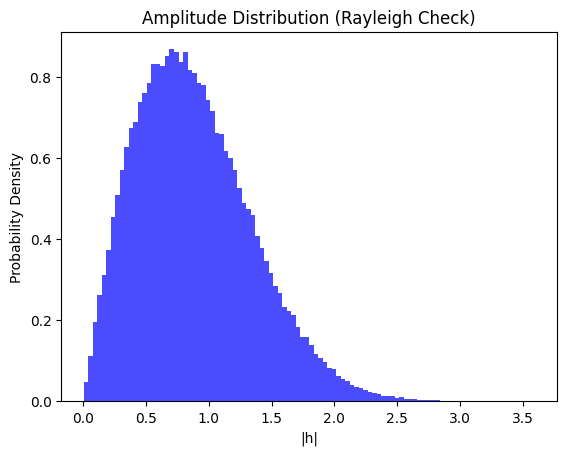

In [ ]:
import matplotlib.pyplot as plt

# 計算振幅 (Magnitude)
abs_h = np.abs(channel_data)

plt.hist(abs_h.flatten(), bins=100, density=True, alpha=0.7, color='blue')
plt.title('Amplitude Distribution (Rayleigh Check)')
plt.xlabel('|h|')
plt.ylabel('Probability Density')
plt.show()

模擬場景: 3GPP 38.901 UMi NLOS
最大多普勒頻移: 9.72 Hz
產生的通道向量維度: (20000,)

數據集已儲存至: 'rayleigh_channel_dataset.mat'


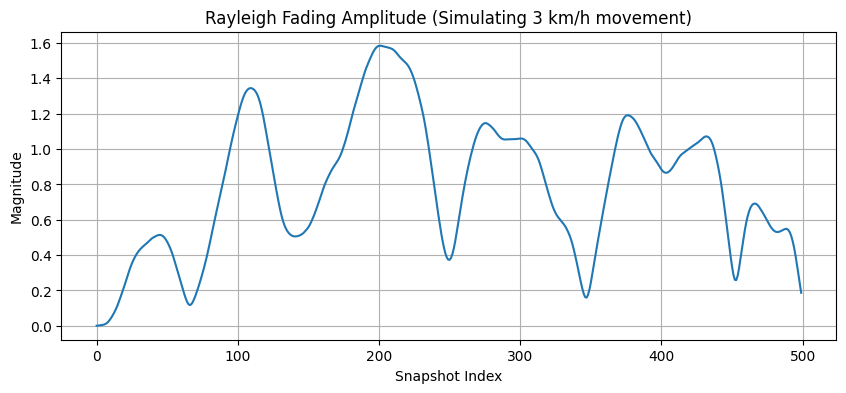

In [ ]:
import numpy as np
import scipy.io as sio
from scipy import signal

# --- 1. 定義模擬參數 (與 MATLAB 腳本一致) ---
fc = 3.5e9               # 中心頻率 3.5 GHz
c = 3e8                  # 光速
num_tx = 1               # SISO
num_rx = 1               # SISO
ue_speed_kmh = 3         # 時速 3 km/h
num_snapshots = 20000    # 樣本總數

# 計算多普勒頻率 (Doppler Frequency)
v = ue_speed_kmh * 1000 / 3600  # 轉換為 m/s
fd = v * fc / c                 # 最大多普勒頻移 (約 9.72 Hz)

# 假設取樣頻率 (Sampling frequency)
# 在 QuaDRiGa 中，這取決於 Snapshots 在 Track 上的間隔。
# 這裡設定 fs 以模擬連續的移動特性
fs = 1000 # 假設每秒 1000 個樣本 (1ms 一抽)

print(f"模擬場景: 3GPP 38.901 UMi NLOS")
print(f"最大多普勒頻移: {fd:.2f} Hz")

# --- 2. 產生具有多普勒特性的瑞利通道 (Correlated Rayleigh Fading) ---
# 瑞利通道在數學上由兩個獨立的高斯隨機過程組成 (實部與虛部)
# 為了模擬移動 (3 km/h)，我們需要對隨機雜訊進行低通濾波 (Jakes Model)

# 產生白雜訊
t = np.arange(num_snapshots) / fs
noise_real = np.random.normal(0, np.sqrt(0.5), num_snapshots)
noise_imag = np.random.normal(0, np.sqrt(0.5), num_snapshots)

# 建立 Jakes 濾波器以模擬多普勒擴散效果
# 這裡簡單使用一個低通濾波器，截止頻率設為 fd
b, a = signal.butter(3, fd / (fs / 2), btype='low')

# 進行濾波，產生具時間相關性的通道係數
h_real = signal.lfilter(b, a, noise_real)
h_imag = signal.lfilter(b, a, noise_imag)

# 組合為複數通道向量 h_siso
h_siso = h_real + 1j * h_imag

# 正規化功率為 1 (Unit Average Power)
h_siso = h_siso / np.std(h_siso)

print(f"產生的通道向量維度: {h_siso.shape}")

# --- 3. 儲存為 .mat 檔案 (供後續 GAN 使用) ---
dataset_filename = 'rayleigh_channel_dataset.mat'
# 為了完美符合 MATLAB 的格式需求，我們將數據包裝在 dict 中
sio.savemat(dataset_filename, {'h_siso': h_siso})

print(f"\n數據集已儲存至: '{dataset_filename}'")

# --- 4. 視覺化驗證 (可選) ---
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(np.abs(h_siso[:500])) # 畫出前 500 個點的振幅變化
plt.title("Rayleigh Fading Amplitude (Simulating 3 km/h movement)")
plt.xlabel("Snapshot Index")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()

In [ ]:
# Exercise 2.4: Channel GAN Implementation (Colab-ready)
# ------------------------------------------------------
# 這份程式是把原始的 Exercise_2.4_starter.py
# 整理成在 Colab 可直接執行的版本。
#
# 功能：
# 1. 從 rayleigh_channel_dataset.mat 載入 h_siso
# 2. 使用 generate_real_samples_with_labels_Rayleigh 產生訓練資料
# 3. 建立 Rayleigh Channel 的 Conditional GAN (WGAN-GP 版本)
# 4. 訓練並定期畫圖到 images/ 目錄
# ------------------------------------------------------

import os
import numpy as np
import scipy.io as sio
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

# ------------------------------------------------------
# Config
# ------------------------------------------------------
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
# 如需指定 GPU，可改成 '0'，若無 GPU 就保持不變或註解掉下一行
# os.environ["CUDA_VISIBLE_DEVICES"] = '0'

tf.set_random_seed(100)
np.random.seed(100)

batch_size = 512
condition_dim = 4       # [Re(x), Im(x), Re(h), Im(h)] → 4 維
Z_dim = 16
model = 'ChannelGAN_Rayleigh_'
data_size = 10000       # 用多少筆 data 訓練（會從產生的資料中截取）

# 16-QAM 星座點（作為全域變數，供 data generator 使用）
mean_set_QAM = np.asarray(
    [-3 - 3j, -3 - 1j, -3 + 1j, -3 + 3j,
     -1 - 3j, -1 - 1j, -1 + 1j, -1 + 3j,
      1 - 3j,  1 - 1j,  1 + 1j,  1 + 3j,
      3 - 3j,  3 - 1j,  3 + 1j,  3 + 3j],
    dtype=np.complex64
)

# ------------------------------------------------------
# 載入 .mat dataset (需預先放在同一個目錄)
# ------------------------------------------------------
mat_file_path = 'rayleigh_channel_dataset.mat'  # 檔名要跟題目一致
mat_data = sio.loadmat(mat_file_path)
h_dataset = mat_data['h_siso'].flatten()       # shape: (N,), complex
print('Loaded h_dataset with shape:', h_dataset.shape)

# ------------------------------------------------------
# Helper functions
# ------------------------------------------------------
def sample_Z(sample_size):
    """從 N(0,1) 取樣 latent noise z。"""
    return np.random.normal(size=sample_size)

def xavier_init(size):
    """
    Xavier initialization for network weights.

    Args:
        size: Shape of the weight tensor.

    Returns:
        Tensor initialized with Xavier distribution.
    """
    in_dim = size[0]
    xavier_stddev = 1. / tf.sqrt(in_dim / 2.)
    return tf.random_normal(shape=size, stddev=xavier_stddev)

# ------------------------------------------------------
# (重點) 產生真實樣本與 conditioning
# ------------------------------------------------------
def generate_real_samples_with_labels_Rayleigh(h_dataset, number=100):
    """
    Generate real (labeled) samples for training the CGAN (Rayleigh channel).

    Steps:
    1. 隨機從 h_dataset 抽取複數通道係數 h。
    2. 為每個樣本隨機產生 16QAM symbol x（使用 mean_set_QAM）。
    3. 模擬通道輸出 y = h*x + n，其中 n 為 2D 高斯雜訊。
    4. 建立 conditioning 向量 [Re(x), Im(x), Re(h), Im(h)] / 3。

    Args:
        h_dataset: 1-D array-like, 含有複數通道係數 h_siso。
        number: 要產生的樣本數。

    Returns:
        received_data: shape = (number, 2)，每列為 [Re(y), Im(y)]。
        conditioning: shape = (number, 4)，每列為 [Re(x), Im(x), Re(h), Im(h)] / 3。
    """
    # 1. 隨機選 h（複數 Rayleigh 通道係數）
    h_complex = np.random.choice(h_dataset, size=number, replace=True)  # shape: (number,)
    h_r = np.real(h_complex)
    h_i = np.imag(h_complex)

    # 2. 產生隨機 16QAM symbol
    symbol_idx = np.random.randint(low=0, high=len(mean_set_QAM), size=number)
    x_complex = mean_set_QAM[symbol_idx]  # shape: (number,)
    x_r = np.real(x_complex)
    x_i = np.imag(x_complex)

    # 3. 通道輸出 y = h * x + n
    y_complex = h_complex * x_complex  # shape: (number,)

    # 加上高斯雜訊（和繪圖區相同的共變異數）
    noise = np.random.multivariate_normal(
        mean=[0, 0],
        cov=[[0.03, 0], [0, 0.03]],
        size=number
    ).astype(np.float32)

    y_r = np.real(y_complex)
    y_i = np.imag(y_complex)

    y_r_noisy = y_r + noise[:, 0]
    y_i_noisy = y_i + noise[:, 1]

    # 4. 輸出與 conditioning
    # received_data: [Re(y), Im(y)]
    received_data = np.stack([y_r_noisy, y_i_noisy], axis=1).astype(np.float32)

    # conditioning: [Re(x), Im(x), Re(h), Im(h)] / 3
    conditioning = np.stack([x_r, x_i, h_r, h_i], axis=1).astype(np.float32) / 3.0

    return received_data, conditioning

# 先產生一批資料供訓練使用
data, one_hot_labels = generate_real_samples_with_labels_Rayleigh(h_dataset, data_size)
print("Generated data shape:", data.shape)
print("Generated conditioning shape:", one_hot_labels.shape)

# ------------------------------------------------------
# Model Definition (WGAN-GP style Conditional GAN)
# ------------------------------------------------------
# Discriminator weights
D_W1 = tf.Variable(xavier_init([2 + condition_dim, 32]))
D_b1 = tf.Variable(tf.zeros(shape=[32]))
D_W2 = tf.Variable(xavier_init([32, 32]))
D_b2 = tf.Variable(tf.zeros(shape=[32]))
D_W3 = tf.Variable(xavier_init([32, 32]))
D_b3 = tf.Variable(tf.zeros(shape=[32]))
D_W4 = tf.Variable(xavier_init([32, 1]))
D_b4 = tf.Variable(tf.zeros(shape=[1]))
theta_D = [D_W1, D_W2, D_W3, D_b1, D_b2, D_b3, D_W4, D_b4]

# Generator weights
G_W1 = tf.Variable(xavier_init([Z_dim + condition_dim, 128]))
G_b1 = tf.Variable(tf.zeros(shape=[128]))
G_W2 = tf.Variable(xavier_init([128, 128]))
G_b2 = tf.Variable(tf.zeros(shape=[128]))
G_W3 = tf.Variable(xavier_init([128, 128]))
G_b3 = tf.Variable(tf.zeros(shape=[128]))
G_W4 = tf.Variable(xavier_init([128, 2]))  # output 2-dim: [Re(y), Im(y)]
G_b4 = tf.Variable(tf.zeros(shape=[2]))
theta_G = [G_W1, G_W2, G_W3, G_b1, G_b2, G_b3, G_W4, G_b4]

# Placeholders
R_sample = tf.placeholder(tf.float32, shape=[None, 2])             # real [Re(y), Im(y)]
Z = tf.placeholder(tf.float32, shape=[None, Z_dim])                # noise
Condition = tf.placeholder(tf.float32, shape=[None, condition_dim])# conditioning

# Generator
def generator_conditional(z, conditioning):
    """Build Generator network."""
    z_combine = tf.concat([z, conditioning], 1)
    G_h1 = tf.nn.relu(tf.matmul(z_combine, G_W1) + G_b1)
    G_h2 = tf.nn.relu(tf.matmul(G_h1, G_W2) + G_b2)
    G_h3 = tf.nn.relu(tf.matmul(G_h2, G_W3) + G_b3)
    G_logit = tf.matmul(G_h3, G_W4) + G_b4
    return G_logit

# Discriminator
def discriminator_conditional(X, conditioning):
    """Build Discriminator network."""
    z_combine = tf.concat([X, conditioning], 1)
    # 注意原始 code 有 /4 的 scaling，這裡保留
    D_h1_real = tf.nn.relu(tf.matmul(z_combine / 4.0, D_W1) + D_b1)
    D_h2_real = tf.nn.relu(tf.matmul(D_h1_real, D_W2) + D_b2)
    D_h3_real = tf.nn.relu(tf.matmul(D_h2_real, D_W3) + D_b3)
    D_logit = tf.matmul(D_h3_real, D_W4) + D_b4
    D_prob = tf.nn.sigmoid(D_logit)
    return D_prob, D_logit

# Graph construction
G_sample = generator_conditional(Z, Condition)
D_prob_real, D_logit_real = discriminator_conditional(R_sample, Condition)
D_prob_fake, D_logit_fake = discriminator_conditional(G_sample, Condition)

# WGAN-GP loss
D_loss = tf.reduce_mean(D_logit_fake) - tf.reduce_mean(D_logit_real)
G_loss = -1 * tf.reduce_mean(D_logit_fake)

lambdda = 5.0
alpha = tf.random_uniform(shape=tf.shape(R_sample), minval=0., maxval=1.)
differences = G_sample - R_sample
interpolates = R_sample + (alpha * differences)
_, D_inter = discriminator_conditional(interpolates, Condition)
gradients = tf.gradients(D_inter, [interpolates])[0]
slopes = tf.sqrt(tf.reduce_sum(tf.square(gradients), reduction_indices=[1]))
gradient_penalty = tf.reduce_mean((slopes - 1.0) ** 2)
D_loss += lambdda * gradient_penalty

D_solver = tf.train.AdamOptimizer(learning_rate=1e-4, beta1=0.5, beta2=0.9).minimize(D_loss, var_list=theta_D)
G_solver = tf.train.AdamOptimizer(learning_rate=1e-4, beta1=0.5, beta2=0.9).minimize(G_loss, var_list=theta_G)

# ------------------------------------------------------
# Training Loop
# ------------------------------------------------------
save_fig_path = model + "images"
if not os.path.exists(save_fig_path):
    os.makedirs(save_fig_path)

saver = tf.train.Saver()
plot_every = 1000  # 每隔多少 iter 存圖
max_iter = 20000   # 訓練總 iterations，可視需求調整

sess = tf.Session()
sess.run(tf.global_variables_initializer())

print("Start training...")

i_plot = 0
for it in range(max_iter):
    start_idx = (it * batch_size) % data_size
    if start_idx + batch_size >= len(data):
        continue

    X_mb = data[start_idx:start_idx + batch_size, :]
    one_hot_labels_mb = one_hot_labels[start_idx:start_idx + batch_size, :]

    # 多次更新 D
    for d_idx in range(10):
        _, D_loss_curr = sess.run([D_solver, D_loss],
                                  feed_dict={R_sample: X_mb,
                                             Z: sample_Z((batch_size, Z_dim)),
                                             Condition: one_hot_labels_mb})

    # 更新 G
    _, G_loss_curr = sess.run([G_solver, G_loss],
                              feed_dict={R_sample: X_mb,
                                         Z: sample_Z((batch_size, Z_dim)),
                                         Condition: one_hot_labels_mb})

    if (it + 1) % 100 == 0:
        print("Iter: {}, D_loss: {:.4f}, G_loss: {:.4f}".format(it + 1, D_loss_curr, G_loss_curr))

    # 定期畫圖
    if (it + 1) % plot_every == 0:
        save_path = saver.save(sess, './Models/ChannelGAN_model_step_' + str(it + 1) + '.ckpt')

        print("Start Plotting at iter", it + 1)
        plt.clf()
        number = 1000

        # 隨機選一個 h 用來畫散佈圖
        h_complex_for_plot = np.random.choice(h_dataset, 1)[0]
        h_r = np.tile(np.real(h_complex_for_plot), number)
        h_i = np.tile(np.imag(h_complex_for_plot), number)
        h_complex = h_r + 1j * h_i

        # 對每一個 QAM symbol 畫真實/生成分佈
        colors = ['b.', 'r+', 'm.', 'c.', 'k.', 'g.', 'y.', 'm.',
                  'bo', 'ro', 'mo', 'co', 'ko', 'go', 'yo', 'bo']
        colors = ['b.', 'b+', 'bx', 'b^', 'b^', 'bx', 'b+', 'b.',
                  'b.', 'b+', 'bx', 'b^', 'b^', 'bx', 'b+', 'b.']

        for idx_symbol in range(len(mean_set_QAM)):
            labels_index = np.tile(idx_symbol, number)
            data_t = mean_set_QAM[labels_index]
            transmit_data = h_complex * data_t
            transmit_data = np.hstack((
                np.real(transmit_data).reshape(len(transmit_data), 1),
                np.imag(transmit_data).reshape(len(transmit_data), 1)
            ))

            gaussion_random = np.random.multivariate_normal(
                [0, 0], [[0.03, 0], [0, 0.03]], number).astype(np.float32)
            received_data = transmit_data + gaussion_random

            conditioning = np.hstack((
                np.real(data_t).reshape(len(data_t), 1),
                np.imag(data_t).reshape(len(data_t), 1),
                h_r.reshape(len(data_t), 1),
                h_i.reshape(len(data_t), 1)
            )) / 3.0

            samples_component = sess.run(G_sample,
                                         feed_dict={Z: sample_Z((number, Z_dim)),
                                                    Condition: conditioning})

            plt.plot(samples_component[:, 0], samples_component[:, 1], colors[idx_symbol])
            plt.plot(transmit_data[:, 0], transmit_data[:, 1], colors[idx_symbol])

        axes = plt.gca()
        axes.set_xlim([-4, 4])
        axes.set_ylim([-4, 4])
        plt.title('Iter: {}, loss(D): {:.2f}, loss(G): {:.2f}'.format(it + 1, D_loss_curr, G_loss_curr))

        fig_name = save_fig_path + '/{}.png'.format(str(i_plot).zfill(3))
        plt.savefig(fig_name, bbox_inches='tight')
        print("Saved figure:", fig_name)
        i_plot += 1

print("Training finished.")
sess.close()


Instructions for updating:
non-resource variables are not supported in the long term


Loaded h_dataset with shape: (20000,)
Generated data shape: (10000, 2)
Generated conditioning shape: (10000, 4)
Start training...
Iter: 100, D_loss: 3.4333, G_loss: -1.4310
Iter: 200, D_loss: 0.6834, G_loss: -0.9179
Iter: 300, D_loss: -5.5230, G_loss: 0.3741
Iter: 400, D_loss: -4.4298, G_loss: 3.4091
Iter: 500, D_loss: -1.9882, G_loss: 1.5676
Iter: 600, D_loss: -3.3005, G_loss: 0.6004
Iter: 700, D_loss: -0.4639, G_loss: -3.9528
Iter: 800, D_loss: 2.1097, G_loss: -0.1705
Iter: 900, D_loss: 1.5753, G_loss: 4.4157
Iter: 1000, D_loss: 1.2611, G_loss: 2.6175
Start Plotting at iter 1000
Saved figure: ChannelGAN_Rayleigh_images/000.png
Iter: 1100, D_loss: -5.9051, G_loss: 0.6993
Iter: 1200, D_loss: -2.0269, G_loss: 2.1811
Iter: 1300, D_loss: -0.9520, G_loss: 4.9085
Iter: 1400, D_loss: -1.3139, G_loss: 1.6399
Iter: 1500, D_loss: 1.3149, G_loss: -2.3208
Iter: 1600, D_loss: 1.1061, G_loss: -1.5777
Iter: 1800, D_loss: 1.9318, G_loss: 1.1939
Iter: 1900, D_loss: 1.6418, G_loss: 2.2924
Iter: 2000, D

Instructions for updating:
Use standard file APIs to delete files with this prefix.


Iter: 7000, D_loss: 0.0061, G_loss: 8.6556
Start Plotting at iter 7000
Saved figure: ChannelGAN_Rayleigh_images/005.png
Iter: 7100, D_loss: 0.7450, G_loss: 7.6644
Iter: 7200, D_loss: -0.1106, G_loss: 7.2150
Iter: 7300, D_loss: -0.5937, G_loss: 8.5412
Iter: 7400, D_loss: 0.4878, G_loss: 9.1552
Iter: 7600, D_loss: -0.6053, G_loss: 13.5189
Iter: 7700, D_loss: -1.1486, G_loss: 15.1701
Iter: 7800, D_loss: -1.3351, G_loss: 15.4173
Iter: 7900, D_loss: -1.6048, G_loss: 15.8282
Iter: 8000, D_loss: -1.8731, G_loss: 16.1357
Start Plotting at iter 8000
Saved figure: ChannelGAN_Rayleigh_images/006.png
Iter: 8100, D_loss: -2.0547, G_loss: 16.7717
Iter: 8200, D_loss: -2.2169, G_loss: 17.8324
Iter: 8300, D_loss: -2.4952, G_loss: 19.2161
Iter: 8400, D_loss: -2.6621, G_loss: 20.6080
Iter: 8500, D_loss: -2.4279, G_loss: 22.5975
Iter: 8600, D_loss: -2.4850, G_loss: 23.8718
Iter: 8700, D_loss: -2.4471, G_loss: 24.6593
Iter: 8800, D_loss: -2.4284, G_loss: 25.6828
Iter: 8900, D_loss: -2.5504, G_loss: 26.3607

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
